# Intro

## Pretrain

Pretrain predicts the next action embedding from the previous sequence of action embeddings.

$$ z_{t+1}^{pred} = T_{\theta}\left(z_{t-L+1}, z_{t-L+2}, \ldots, z_t\right) $$

where $T_{\theta}$ is the pretrained transformer with parameters $\theta$. Next we define what one action embedding is. $z_t$ is the flattened normalized CP-background relation matrix at frame $t$.

$$ z_t = \operatorname{flatten}\left(A_t^{norm}\right) $$

The normalized action embedding matrix contains the relation between object control points and selected background points.

$$ A_t^{norm} \in \mathbb{R}^{K \times N \times 2} $$

The flattened action embedding is a vector used as one transformer token.

$$ z_t \in \mathbb{R}^{D} $$

The flattened embedding dimension is the total number of values in the normalized action embedding matrix.

$$ D = K \cdot N \cdot 2 $$

The factor $2$ comes from the two relation channels: $x$ and $y$. The pretraining target is the true next action embedding computed directly from the next video frame.

$$ z_{t+1}^{true} = \operatorname{flatten}\left(A_{t+1}^{norm}\right) $$

The pretraining loss compares the predicted next action embedding with the true next action embedding.

$$ \mathcal{L}_{pretrain} = \operatorname{MSE}\left(z_{t+1}^{pred}, z_{t+1}^{true}\right) $$

After pretraining, the transformer has learned the temporal dynamics of action embeddings. It can predict how the CP-background relation should change in the next frame.

$$ T_{\theta}: z_{t-L+1:t} \mapsto z_{t+1}^{pred} $$

## AIN

Fine-tuning adds an agent-specific Action Inference Net that maps the predicted action embedding into the agent action space. $$\hat{a}_{t+1} = \operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}\right)$$ where $\operatorname{AIN}_{\phi}$ is the Action Inference Net with parameters $\phi$. The input dimension of $\operatorname{AIN}_{\phi}$ is the action embedding dimension. $$D = K \cdot N \cdot 2$$ The output of $\operatorname{AIN}_{\phi}$ must match the action space of the specific agent. For Lunar Lander, the action space is discrete with four possible actions. $$\hat{a}_{t+1} \in \mathbb{R}^{|\mathcal{A}|}, \quad |\mathcal{A}| = 4$$ The AIN output is a vector of action logits. The predicted action is selected from these logits. $$a_{t+1}^{pred} = \arg\max\left(\hat{a}_{t+1}\right)$$ We do not start from expert action labels. Instead, we create pseudo-labels by counterfactual re-environment rollouts. For each candidate action, we replay the same environment state up to frame $t$, apply that candidate action, render the next frame, encode it again with the CP-background pipeline, and compare it with the true next## AIN

Fine-tuning adds an agent-specific Action Inference Net that maps the predicted action embedding into the agent action space.

$$\hat{a}_{t+1} = \operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}\right)$$

where $\operatorname{AIN}_{\phi}$ is the Action Inference Net with parameters $\phi$. The input dimension of $\operatorname{AIN}_{\phi}$ is the action embedding dimension.

$$D = K \cdot N \cdot 2$$

The output of $\operatorname{AIN}_{\phi}$ must match the action space of the specific agent. For Lunar Lander, the action space is discrete with four possible actions.

$$\hat{a}_{t+1} \in \mathbb{R}^{|\mathcal{A}|}, \quad |\mathcal{A}| = 4$$

The AIN output is a vector of action logits. The predicted action is selected from these logits.

$$a_{t+1}^{pred} = \arg\max\left(\hat{a}_{t+1}\right)$$

We do not start from expert action labels. Instead, we create pseudo-labels by counterfactual re-environment rollouts. For each candidate action, we replay the same environment state up to frame $t$, apply that candidate action, render the next frame, encode it again with the CP-background pipeline, and compare it with the true next CP-background relation.

$$\operatorname{env.step}\left(a\right) \rightarrow frame_{t+1}^{reenv(a)} \rightarrow A_{t+1}^{reenv(a)}$$

The pseudo-label is the action whose re-environment next relation is closest to the true next relation.

$$a_{t+1}^{*} = \arg\min_{a \in \mathcal{A}} \operatorname{MSE}\left(A_{t+1}^{reenv(a)}, A_{t+1}^{true}\right)$$

Then AIN is trained as an action-space classifier on these pseudo-labels.

$$\mathcal{L}_{AIN} = \operatorname{CE}\left(\operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}\right), a_{t+1}^{*}\right)$$

After training, the final inference loop is: history frames become action embeddings, the pretrained transformer predicts the next action embedding, AIN maps that embedding to an executable action, and the environment executes that action.

$$z_{t+1}^{pred} = T_{\theta}\left(z_{t-L+1:t}\right), \quad a_{t+1}^{pred} = \arg\max\left(\operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}\right)\right)$$

This is not universal video-only training, because counterfactual grounding requires an environment or simulator. The research signal is that the action embedding can be grounded into a concrete action interface without direct expert action labels, using only the consequence of each action in the simulator. CP-background relation. $$\operatorname{env.step}\left(a\right) \rightarrow frame_{t+1}^{reenv(a)} \rightarrow A_{t+1}^{reenv(a)}$$ The pseudo-label is the action whose re-environment next relation is closest to the true next relation. $$a_{t+1}^{*} = \arg\min_{a \in \mathcal{A}} \operatorname{MSE}\left(A_{t+1}^{reenv(a)}, A_{t+1}^{true}\right)$$ Then AIN is trained as an action-space classifier on these pseudo-labels. $$\mathcal{L}_{AIN} = \operatorname{CE}\left(\operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}\right), a_{t+1}^{*}\right)$$ After training, the final inference loop is: history frames become action embeddings, the pretrained transformer predicts the next action embedding, AIN maps that embedding to an executable action, and the environment executes that action. $$z_{t+1}^{pred} = T_{\theta}\left(z_{t-L+1:t}\right), \quad a_{t+1}^{pred} = \arg\max\left(\operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}\right)\right)$$ This is not universal video-only training, because counterfactual grounding requires an environment or simulator. The research signal is that the action embedding can be grounded into a concrete action interface without direct expert action labels, using only the consequence of each action in the simulator.

# Imports and Paths

In [1]:
# Imports and Paths

import json
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

SOURCE_PRETRAIN_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "pretrain"
SOURCE_PRETRAIN_MODELS_DIR = SOURCE_PRETRAIN_ARTIFACTS_DIR / "models"
SOURCE_PRETRAIN_TOKENS_DIR = SOURCE_PRETRAIN_ARTIFACTS_DIR / "tokens"
SOURCE_PRETRAIN_EMBEDDINGS_DIR = SOURCE_PRETRAIN_ARTIFACTS_DIR / "action_embeddings"

FINETUNE_ARTIFACTS_DIR = NOTEBOOKS_DIR / "artifacts" / "lunarlander_finetune"
FINETUNE_MODELS_DIR = FINETUNE_ARTIFACTS_DIR / "models"
FINETUNE_CHECKPOINTS_DIR = FINETUNE_MODELS_DIR / "checkpoints"
FINETUNE_PLOTS_DIR = FINETUNE_ARTIFACTS_DIR / "plots"
FINETUNE_DATA_DIR = FINETUNE_ARTIFACTS_DIR / "data"

TRANSFORMER_TEST_PLOTS_DIR = FINETUNE_PLOTS_DIR / "transformer_prediction_tests"
AIN_PLOTS_DIR = FINETUNE_PLOTS_DIR / "ain_prediction_tests"
LOSS_PLOTS_DIR = FINETUNE_PLOTS_DIR / "loss"

for path in [
    FINETUNE_ARTIFACTS_DIR,
    FINETUNE_MODELS_DIR,
    FINETUNE_CHECKPOINTS_DIR,
    FINETUNE_PLOTS_DIR,
    FINETUNE_DATA_DIR,
    TRANSFORMER_TEST_PLOTS_DIR,
    AIN_PLOTS_DIR,
    LOSS_PLOTS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SOURCE_PRETRAIN_ARTIFACTS_DIR:", SOURCE_PRETRAIN_ARTIFACTS_DIR)
print("FINETUNE_ARTIFACTS_DIR:", FINETUNE_ARTIFACTS_DIR)
print("TRANSFORMER_TEST_PLOTS_DIR:", TRANSFORMER_TEST_PLOTS_DIR)
print("AIN_PLOTS_DIR:", AIN_PLOTS_DIR)
print("LOSS_PLOTS_DIR:", LOSS_PLOTS_DIR)
print("device:", device)

PROJECT_ROOT: /Users/adriankazi/Desktop/Action Inference
SOURCE_PRETRAIN_ARTIFACTS_DIR: /Users/adriankazi/Desktop/Action Inference/artifacts/pretrain
FINETUNE_ARTIFACTS_DIR: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune
TRANSFORMER_TEST_PLOTS_DIR: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/transformer_prediction_tests
AIN_PLOTS_DIR: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests
LOSS_PLOTS_DIR: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/loss
device: cpu


# Load Pretrained Transformer

In [2]:
# Load Pretrained Transformer

pretrained_model_path = SOURCE_PRETRAIN_MODELS_DIR / "action_embedding_transformer.pt"
pretrain_config_path = SOURCE_PRETRAIN_MODELS_DIR / "action_embedding_transformer_config.json"

assert pretrained_model_path.exists(), pretrained_model_path
assert pretrain_config_path.exists(), pretrain_config_path

checkpoint = torch.load(
    pretrained_model_path,
    map_location=device,
)

if "config" in checkpoint:
    pretrain_config = checkpoint["config"]
else:
    with open(pretrain_config_path, "r") as f:
        pretrain_config = json.load(f)

seq_len = pretrain_config["seq_len"]
embed_dim = pretrain_config["embed_dim"]
n_heads = pretrain_config["n_heads"]
n_blocks = pretrain_config["n_blocks"]
dropout = pretrain_config["dropout"]
flattened_dim = pretrain_config["flattened_dim"]

print("pretrained_model_path:", pretrained_model_path)
print("checkpoint keys:", checkpoint.keys() if isinstance(checkpoint, dict) else type(checkpoint))
print("seq_len:", seq_len)
print("embed_dim:", embed_dim)
print("n_heads:", n_heads)
print("n_blocks:", n_blocks)
print("dropout:", dropout)
print("flattened_dim:", flattened_dim)
print("checkpoint step:", checkpoint.get("step") if isinstance(checkpoint, dict) else None)

pretrained_model_path: /Users/adriankazi/Desktop/Action Inference/artifacts/pretrain/models/action_embedding_transformer.pt
checkpoint keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'control_point_dim', 'background_dim', 'relation_channels', 'flattened_dim', 'seq_len', 'batch_size', 'embed_dim', 'n_heads', 'n_blocks', 'dropout'])
seq_len: 4
embed_dim: 256
n_heads: 4
n_blocks: 4
dropout: 0.1
flattened_dim: 1200
checkpoint step: None


## Test Action Embedding ($A$)

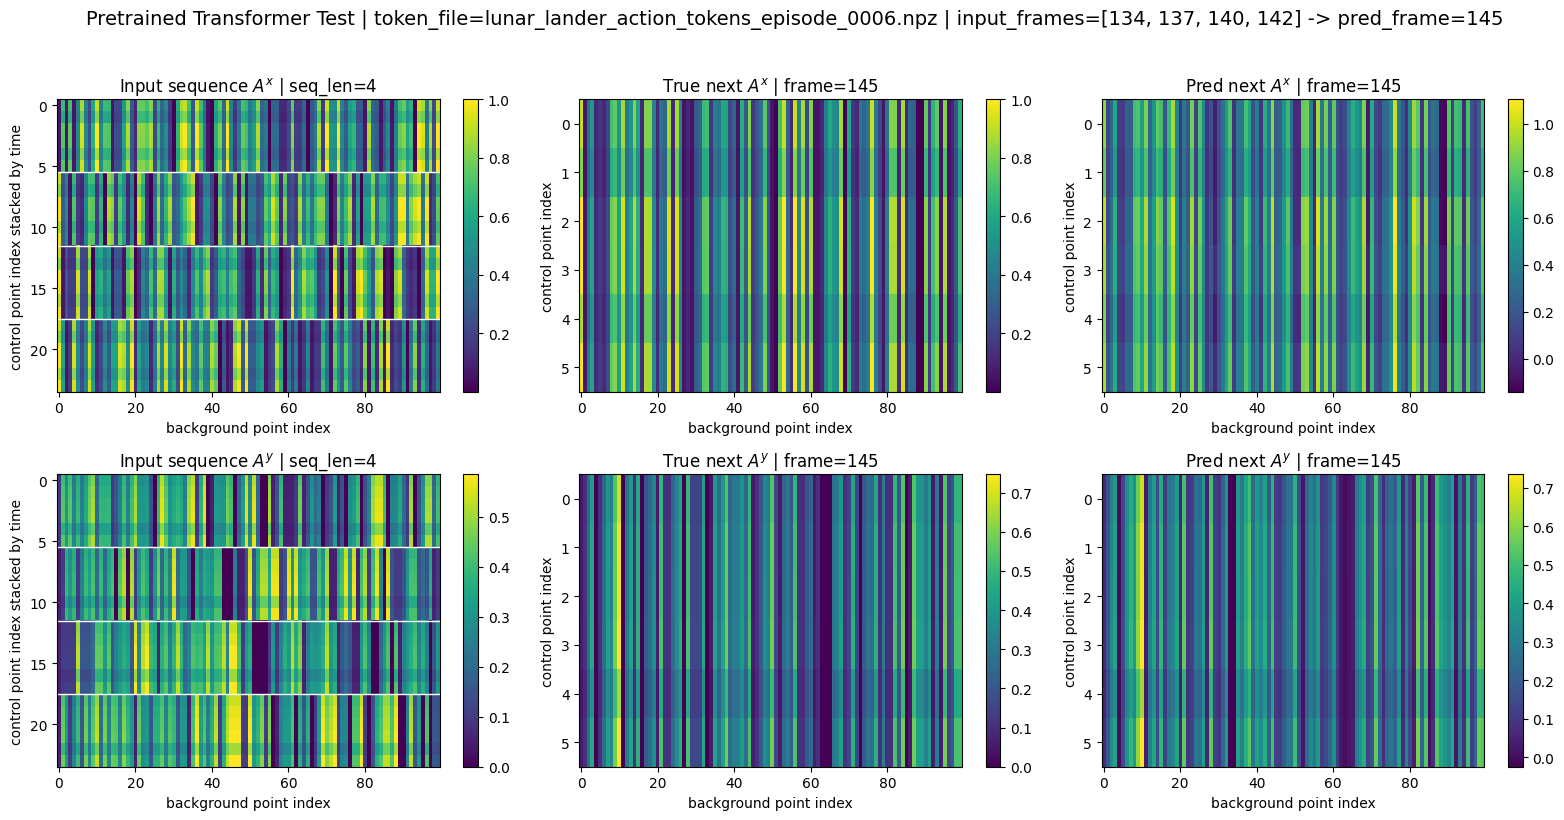

token_path: /Users/adriankazi/Desktop/Action Inference/artifacts/pretrain/tokens/lunar_lander_action_tokens_episode_0006.npz
input frames: [134, 137, 140, 142]
true next frame: 145
X_seq shape: (4, 1200)
pred_next shape: (1200,)
MSE: 0.0034932112
saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/transformer_prediction_tests/pretrained_transformer_random_sequence_test.png


In [3]:
# Pretrained Transformer - Random Sequence Test

from src.pretraining.model import ActionEmbeddingModel

control_point_dim = pretrain_config.get("control_point_dim", 6)
relation_channels = pretrain_config.get("relation_channels", 2)
background_dim = pretrain_config.get(
    "background_dim",
    flattened_dim // (control_point_dim * relation_channels),
)

model = ActionEmbeddingModel(
    flattened_dim=flattened_dim,
    seq_len=seq_len,
    embed_dim=embed_dim,
    n_heads=n_heads,
    n_blocks=n_blocks,
    dropout=dropout,
).to(device)

state_dict = checkpoint.get("model_state_dict", checkpoint)
state_dict = {
    key.replace("transformerBlocks", "transformer_blocks"): value
    for key, value in state_dict.items()
}

model.load_state_dict(state_dict)
model.eval()

token_paths = sorted(SOURCE_PRETRAIN_TOKENS_DIR.glob("*.npz"))
token_path = np.random.choice(token_paths)

token_data = np.load(token_path)
tokens = token_data["tokens"].astype(np.float32)
frames = token_data["frames"]

max_start = len(tokens) - seq_len - 1
start = np.random.randint(0, max_start + 1)

X_seq = tokens[start:start + seq_len]
true_next = tokens[start + seq_len]
seq_frames = frames[start:start + seq_len]
true_next_frame = frames[start + seq_len]

with torch.no_grad():
    X_tensor = torch.tensor(X_seq[None], dtype=torch.float32).to(device)
    pred_next = model(X_tensor)[0, -1].cpu().numpy()

A_seq = X_seq.reshape(seq_len, control_point_dim, background_dim, relation_channels)
A_true = true_next.reshape(control_point_dim, background_dim, relation_channels)
A_pred = pred_next.reshape(control_point_dim, background_dim, relation_channels)

A_seq_x = np.concatenate([A_seq[t, :, :, 0] for t in range(seq_len)], axis=0)
A_seq_y = np.concatenate([A_seq[t, :, :, 1] for t in range(seq_len)], axis=0)

A_true_x = A_true[:, :, 0]
A_true_y = A_true[:, :, 1]

A_pred_x = A_pred[:, :, 0]
A_pred_y = A_pred[:, :, 1]

fig, ax = plt.subplots(2, 3, figsize=(16, 8))

im00 = ax[0, 0].imshow(A_seq_x, cmap="viridis", aspect="auto")
ax[0, 0].set_title(f"Input sequence $A^x$ | seq_len={seq_len}")
ax[0, 0].set_xlabel("background point index")
ax[0, 0].set_ylabel("control point index stacked by time")
for t in range(1, seq_len):
    ax[0, 0].axhline(t * control_point_dim - 0.5, color="white", linewidth=1)
fig.colorbar(im00, ax=ax[0, 0])

im01 = ax[0, 1].imshow(A_true_x, cmap="viridis", aspect="auto")
ax[0, 1].set_title(f"True next $A^x$ | frame={true_next_frame}")
ax[0, 1].set_xlabel("background point index")
ax[0, 1].set_ylabel("control point index")
fig.colorbar(im01, ax=ax[0, 1])

im02 = ax[0, 2].imshow(A_pred_x, cmap="viridis", aspect="auto")
ax[0, 2].set_title(f"Pred next $A^x$ | frame={true_next_frame}")
ax[0, 2].set_xlabel("background point index")
ax[0, 2].set_ylabel("control point index")
fig.colorbar(im02, ax=ax[0, 2])

im10 = ax[1, 0].imshow(A_seq_y, cmap="viridis", aspect="auto")
ax[1, 0].set_title(f"Input sequence $A^y$ | seq_len={seq_len}")
ax[1, 0].set_xlabel("background point index")
ax[1, 0].set_ylabel("control point index stacked by time")
for t in range(1, seq_len):
    ax[1, 0].axhline(t * control_point_dim - 0.5, color="white", linewidth=1)
fig.colorbar(im10, ax=ax[1, 0])

im11 = ax[1, 1].imshow(A_true_y, cmap="viridis", aspect="auto")
ax[1, 1].set_title(f"True next $A^y$ | frame={true_next_frame}")
ax[1, 1].set_xlabel("background point index")
ax[1, 1].set_ylabel("control point index")
fig.colorbar(im11, ax=ax[1, 1])

im12 = ax[1, 2].imshow(A_pred_y, cmap="viridis", aspect="auto")
ax[1, 2].set_title(f"Pred next $A^y$ | frame={true_next_frame}")
ax[1, 2].set_xlabel("background point index")
ax[1, 2].set_ylabel("control point index")
fig.colorbar(im12, ax=ax[1, 2])

plt.suptitle(
    f"Pretrained Transformer Test | token_file={Path(token_path).name} | "
    f"input_frames={seq_frames.tolist()} -> pred_frame={int(true_next_frame)}",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plot_path = TRANSFORMER_TEST_PLOTS_DIR / "pretrained_transformer_random_sequence_test.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


print("token_path:", token_path)
print("input frames:", seq_frames.tolist())
print("true next frame:", int(true_next_frame))
print("X_seq shape:", X_seq.shape)
print("pred_next shape:", pred_next.shape)
print("MSE:", np.mean((pred_next - true_next) ** 2))
print("saved plot:", plot_path)

## Test Prediction

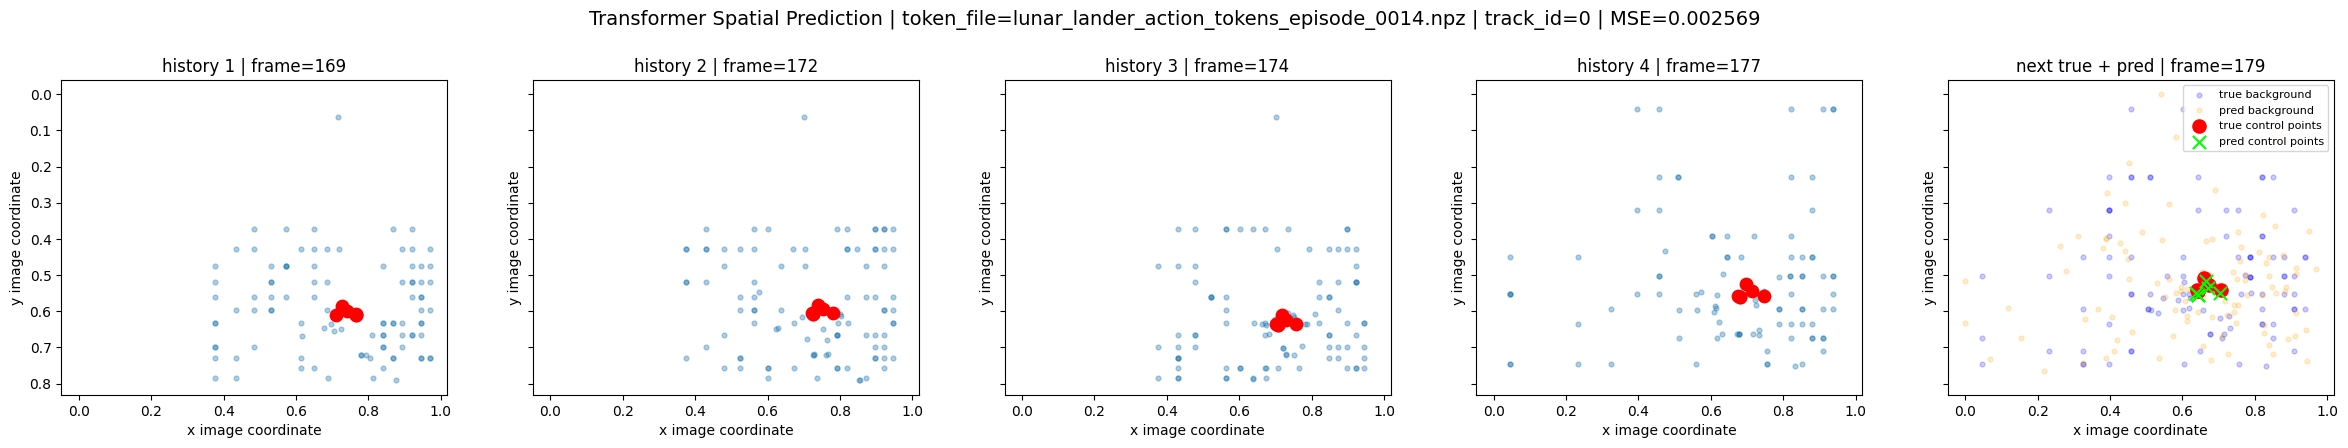

token_path: /Users/adriankazi/Desktop/Action Inference/artifacts/pretrain/tokens/lunar_lander_action_tokens_episode_0014.npz
input frames: [169, 172, 174, 177]
true next frame: 179
track_id: 0
MSE: 0.0025694652
saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/transformer_prediction_tests/pretrained_transformer_spatial_sequence_test.png


In [4]:
# Pretrained Transformer - Spatial Sequence Test

from src.pretraining.model import ActionEmbeddingModel

control_point_dim = pretrain_config.get("control_point_dim", 6)
relation_channels = pretrain_config.get("relation_channels", 2)
background_dim = pretrain_config.get(
    "background_dim",
    flattened_dim // (control_point_dim * relation_channels),
)

model = ActionEmbeddingModel(
    flattened_dim=flattened_dim,
    seq_len=seq_len,
    embed_dim=embed_dim,
    n_heads=n_heads,
    n_blocks=n_blocks,
    dropout=dropout,
).to(device)

state_dict = checkpoint.get("model_state_dict", checkpoint)
state_dict = {
    key.replace("transformerBlocks", "transformer_blocks"): value
    for key, value in state_dict.items()
}

model.load_state_dict(state_dict)
model.eval()

token_paths = sorted(SOURCE_PRETRAIN_TOKENS_DIR.glob("*.npz"))
token_path = np.random.choice(token_paths)

token_data = np.load(token_path)
tokens = token_data["tokens"].astype(np.float32)
frames = token_data["frames"]
track_ids = token_data["track_ids"] if "track_ids" in token_data else np.zeros(len(tokens), dtype=int)

max_start = len(tokens) - seq_len - 1
start = np.random.randint(0, max_start + 1)

X_seq = tokens[start:start + seq_len]
true_next = tokens[start + seq_len]
seq_frames = frames[start:start + seq_len]
true_next_frame = frames[start + seq_len]
track_id = int(track_ids[start])

with torch.no_grad():
    X_tensor = torch.tensor(X_seq[None], dtype=torch.float32).to(device)
    pred_next = model(X_tensor)[0, -1].cpu().numpy()

def token_to_xy(token):
    A = token.reshape(control_point_dim, background_dim, relation_channels)
    A_x = A[:, :, 0]
    A_y = A[:, :, 1]

    x_cp = np.sqrt(np.maximum(A_x.mean(axis=1), 0.0))
    y_cp = np.sqrt(np.maximum(A_y.mean(axis=1), 0.0))

    x_bckg = np.sqrt(np.maximum(A_x.mean(axis=0), 0.0))
    y_bckg = np.sqrt(np.maximum(A_y.mean(axis=0), 0.0))

    return x_cp, y_cp, x_bckg, y_bckg

fig, ax = plt.subplots(1, seq_len + 1, figsize=(24, 4), sharex=True, sharey=True)

for idx in range(seq_len):
    x_cp, y_cp, x_bckg, y_bckg = token_to_xy(X_seq[idx])

    ax[idx].scatter(
        x_bckg,
        y_bckg,
        s=12,
        alpha=0.35,
        label="background points",
    )

    ax[idx].scatter(
        x_cp,
        y_cp,
        s=80,
        c="red",
        label="control points",
    )

    ax[idx].invert_yaxis()
    ax[idx].set_title(f"history {idx + 1} | frame={seq_frames[idx]}")
    ax[idx].set_xlabel("x image coordinate")
    ax[idx].set_ylabel("y image coordinate")
    ax[idx].set_aspect("equal", adjustable="box")

x_cp_true, y_cp_true, x_bckg_true, y_bckg_true = token_to_xy(true_next)
x_cp_pred, y_cp_pred, x_bckg_pred, y_bckg_pred = token_to_xy(pred_next)

ax[-1].scatter(
    x_bckg_true,
    y_bckg_true,
    s=12,
    alpha=0.20,
    c="blue",
    label="true background",
)

ax[-1].scatter(
    x_bckg_pred,
    y_bckg_pred,
    s=12,
    alpha=0.20,
    c="orange",
    label="pred background",
)

ax[-1].scatter(
    x_cp_true,
    y_cp_true,
    s=90,
    c="red",
    label="true control points",
)

ax[-1].scatter(
    x_cp_pred,
    y_cp_pred,
    s=90,
    c="lime",
    marker="x",
    label="pred control points",
)

ax[-1].invert_yaxis()
ax[-1].set_title(f"next true + pred | frame={true_next_frame}")
ax[-1].set_xlabel("x image coordinate")
ax[-1].set_ylabel("y image coordinate")
ax[-1].set_aspect("equal", adjustable="box")
ax[-1].legend(loc="upper right", fontsize=8)

plt.suptitle(
    f"Transformer Spatial Prediction | token_file={Path(token_path).name} | "
    f"track_id={track_id} | MSE={np.mean((pred_next - true_next) ** 2):.6f}",
    fontsize=14,
    y=1.05,
)
plt.tight_layout()
plot_path = TRANSFORMER_TEST_PLOTS_DIR / "pretrained_transformer_spatial_sequence_test.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


print("token_path:", token_path)
print("input frames:", seq_frames.tolist())
print("true next frame:", int(true_next_frame))
print("track_id:", track_id)
print("MSE:", np.mean((pred_next - true_next) ** 2))
print("saved plot:", plot_path)

# Re-Env Fine-Tune Helpers


In [5]:
# Re-Env Fine-Tune Helpers

import cv2
import gymnasium as gym
from gymnasium.envs.box2d.lunar_lander import heuristic
from src.pretraining.model import ActionEmbeddingModel

ACTION_NAMES = {
    0: "noop",
    1: "left_engine",
    2: "main_engine",
    3: "right_engine",
}

CONTROL_POINT_NAMES = [
    "centroid",
    "axis_front",
    "axis_back",
    "axis_left",
    "axis_right",
    "contact_low",
]

N_BACKGROUND_POINTS = background_dim
ACTION_SPACE_DIM = len(ACTION_NAMES)
EPS = 1e-8


def build_pretrained_transformer():
    transformer = ActionEmbeddingModel(
        flattened_dim=flattened_dim,
        seq_len=seq_len,
        embed_dim=embed_dim,
        n_heads=n_heads,
        n_blocks=n_blocks,
        dropout=dropout,
    ).to(device)

    state_dict = checkpoint.get("model_state_dict", checkpoint)
    state_dict = {
        key.replace("transformerBlocks", "transformer_blocks"): value
        for key, value in state_dict.items()
    }

    transformer.load_state_dict(state_dict)
    transformer.eval()
    return transformer


pretrained_transformer = build_pretrained_transformer()


def mask_to_record(mask, object_id=0):
    ys, xs = np.nonzero(mask)
    if len(xs) == 0:
        return None

    x1, x2 = int(xs.min()), int(xs.max()) + 1
    y1, y2 = int(ys.min()), int(ys.max()) + 1

    return {
        "object_id": object_id,
        "mask": mask.astype(bool),
        "box": (x1, y1, x2, y2),
        "area": int(mask.sum()),
        "centroid": (float(xs.mean()), float(ys.mean())),
    }


def largest_connected_component(mask, min_area=20):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8),
        connectivity=8,
    )

    if num_labels <= 1:
        return np.zeros_like(mask, dtype=bool)

    areas = stats[1:, cv2.CC_STAT_AREA]
    best = int(np.argmax(areas)) + 1

    if areas[best - 1] < min_area:
        return np.zeros_like(mask, dtype=bool)

    return labels == best


def lunar_lander_agent_records(frame):
    rgb = frame.astype(np.int16)
    red = rgb[:, :, 0]
    green = rgb[:, :, 1]
    blue = rgb[:, :, 2]
    brightness = rgb.mean(axis=2)
    colorfulness = np.max(rgb, axis=2) - np.min(rgb, axis=2)

    h, w = frame.shape[:2]
    yy, xx = np.indices((h, w))

    scene_window = (
        (yy < int(h * 0.82))
        & (xx > int(w * 0.08))
        & (xx < int(w * 0.92))
    )

    white_terrain = (red > 180) & (green > 180) & (blue > 180) & (colorfulness < 55)
    yellow_flags = (red > 150) & (green > 120) & (blue < 110)

    lander_body = (
        (blue > 95)
        & (red > 45)
        & (green > 40)
        & (blue > red + 10)
        & (blue > green + 5)
    )

    lander_legs = (
        (blue > 60)
        & (green > 45)
        & (red < 170)
        & (colorfulness > 18)
    )

    thruster_flame = (
        (red > 120)
        & (green < 145)
        & (blue < 180)
        & (brightness > 40)
    )

    mask = (
        scene_window
        & ~white_terrain
        & ~yellow_flags
        & (lander_body | lander_legs | thruster_flame)
    )

    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_CLOSE,
        np.ones((5, 5), dtype=np.uint8),
        iterations=1,
    ).astype(bool)

    component = largest_connected_component(mask, min_area=25)
    record = mask_to_record(component, object_id=0)
    return [] if record is None else [record]


def control_points_from_record(record):
    mask = record["mask"].astype(bool)
    ys, xs = np.nonzero(mask)
    x1, y1, x2, y2 = record["box"]
    cx, cy = record["centroid"]

    if len(xs) == 0:
        return []

    point_candidates = {
        "centroid": (cx, cy),
        "axis_front": (float(xs[np.argmin(ys)]), float(ys.min())),
        "axis_back": (float(xs[np.argmax(ys)]), float(ys.max())),
        "axis_left": (float(xs.min()), float(ys[np.argmin(xs)])),
        "axis_right": (float(xs.max()), float(ys[np.argmax(xs)])),
        "contact_low": (float(xs[np.argmax(ys)]), float(ys.max())),
    }

    rows = []
    for point_name in CONTROL_POINT_NAMES:
        x, y = point_candidates[point_name]
        rows.append(
            {
                "track_id": 0,
                "point_name": point_name,
                "x": float(x),
                "y": float(y),
                "box_x1": x1,
                "box_y1": y1,
                "box_x2": x2,
                "box_y2": y2,
                "area": record["area"],
                "class_name": "lunar_lander_agent",
                "source": "env_specific_color_geometry",
            }
        )

    return rows


def frame_control_points_df(frame):
    rows = []
    records = lunar_lander_agent_records(frame)
    for record in records:
        rows.extend(control_points_from_record(record))

    if not rows:
        return pd.DataFrame(columns=["track_id", "point_name", "x", "y"])

    cp_df = pd.DataFrame(rows)
    cp_df["point_name"] = pd.Categorical(
        cp_df["point_name"],
        categories=CONTROL_POINT_NAMES,
        ordered=True,
    )
    return cp_df.sort_values(["track_id", "point_name"]).reset_index(drop=True)


def surface_grid_background_mask(frame):
    records = lunar_lander_agent_records(frame)
    active_mask = np.zeros(frame.shape[:2], dtype=bool)

    for record in records:
        active_mask |= record["mask"]

    active_mask = cv2.dilate(
        active_mask.astype(np.uint8),
        np.ones((13, 13), dtype=np.uint8),
        iterations=1,
    ).astype(bool)

    bg_mask = ~active_mask
    return bg_mask, active_mask, records


def make_surface_grid_points(bg_mask, step=32):
    h, w = bg_mask.shape
    points = []

    for y in range(12, h, step):
        for x in range(12, w, step):
            if bg_mask[y, x]:
                points.append((float(x), float(y)))

    return np.asarray(points, dtype=np.float32)


def select_fixed_background_points(points, n_points=N_BACKGROUND_POINTS):
    if len(points) == 0:
        return np.zeros((n_points, 2), dtype=np.float32)

    if len(points) >= n_points:
        indices = np.linspace(0, len(points) - 1, n_points).round().astype(int)
        return points[indices].astype(np.float32)

    pad_count = n_points - len(points)
    pad = np.repeat(points[-1:], pad_count, axis=0)
    return np.concatenate([points, pad], axis=0).astype(np.float32)


def frame_to_action_embedding(frame):
    cp_df = frame_control_points_df(frame)

    if len(cp_df) != control_point_dim:
        return None

    bg_mask, _, _ = surface_grid_background_mask(frame)
    bg_points = select_fixed_background_points(
        make_surface_grid_points(bg_mask, step=32),
        n_points=background_dim,
    )

    X_cp = cp_df[["x"]].to_numpy(dtype=np.float32)
    Y_cp = cp_df[["y"]].to_numpy(dtype=np.float32)
    X_bckg = bg_points[:, [0]].astype(np.float32)
    Y_bckg = bg_points[:, [1]].astype(np.float32)

    A_x = X_cp @ X_bckg.T
    A_y = Y_cp @ Y_bckg.T
    A = np.stack([A_x, A_y], axis=-1).astype(np.float32)

    A_min = A.min()
    A_max = A.max()
    A_norm = (A - A_min) / (A_max - A_min + EPS)
    token = A_norm.reshape(-1).astype(np.float32)

    return {
        "A_norm": A_norm.astype(np.float32),
        "token": token,
        "cp_df": cp_df,
        "background_points": bg_points,
    }


def rollout_lunar_lander(seed, max_steps=220):
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, info = env.reset(seed=int(seed))

    frames = [env.render()]
    observations = [obs.copy()]
    actions = []
    rewards = []

    for _ in range(max_steps):
        action = int(heuristic(env.unwrapped, obs))
        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(action)
        rewards.append(float(reward))
        observations.append(obs.copy())
        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

    return {
        "frames": np.asarray(frames),
        "observations": np.asarray(observations, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.int64),
        "rewards": np.asarray(rewards, dtype=np.float32),
    }


def replay_env_to_frame(seed, actions, frame_idx):
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, info = env.reset(seed=int(seed))

    for action in actions[:frame_idx]:
        obs, reward, terminated, truncated, info = env.step(int(action))
        if terminated or truncated:
            break

    return env, obs


def predict_next_token(input_tokens):
    with torch.no_grad():
        x = torch.tensor(input_tokens[None], dtype=torch.float32).to(device)
        return pretrained_transformer(x)[0, -1].cpu().numpy().astype(np.float32)


print("helpers ready")
print("control_point_dim:", control_point_dim)
print("background_dim:", background_dim)
print("relation_channels:", relation_channels)
print("flattened_dim:", flattened_dim)
print("action_space_dim:", ACTION_SPACE_DIM)


helpers ready
control_point_dim: 6
background_dim: 100
relation_channels: 2
flattened_dim: 1200
action_space_dim: 4


# Action Inference Net

In [6]:
# Action Inference Net

class ActionInferenceNet(nn.Module):
    def __init__(self, input_dim, action_space_dim, hidden_dim=512, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, action_space_dim),
        )

    def forward(self, z_pred):
        return self.net(z_pred)


ACTION_SPACE_DIM = 4

ain_model = ActionInferenceNet(
    input_dim=flattened_dim,
    action_space_dim=ACTION_SPACE_DIM,
    hidden_dim=512,
    dropout=0.1,
).to(device)

ain_model

ActionInferenceNet(
  (net): Sequential(
    (0): LayerNorm((1200,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=1200, out_features=512, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=512, out_features=4, bias=True)
  )
)

# Fine-Tune Re-Env Coupled Loop

In this section we fine-tune the Action Inference Net using a coupled re-environment loop. The true reference comes from the pretrain episode data, but we do not compare absolute next relations directly. First, we compute one shared scalar normalization for the whole pretrain episode and use the same normalization for both the true pretrain relation and the re-env relation. $$A_t^{epnorm}=rac{A_t-A_{episode}^{min}}{A_{episode}^{max}-A_{episode}^{min}+\epsilon}$$ Then we compare motion deltas, not absolute frame states. $$\Delta A_{t+1}^{true}=A_{t+1}^{true,epnorm}-A_t^{true,epnorm}$$ For every candidate action, we replay the re-env state to time $t$, apply the candidate action, encode the resulting frame again through CP/background/action-embedding, normalize it with the same episode statistics, and compute the re-env delta. $$\Delta A_{t+1}^{reenv(a)}=A_{t+1}^{reenv(a),epnorm}-A_t^{reenv,epnorm}$$ The benchmark action is the action whose re-env delta is closest to the true pretrain delta. $$a_{t+1}^{*}=rg\min_{a\in\mathcal{A}}\operatorname{MSE}\left(\Delta A_{t+1}^{reenv(a)},\Delta A_{t+1}^{true}ight)$$ AIN receives the transformer predicted next action embedding and is trained as an action-space classifier against this benchmark action. $$z_{t+1}^{pred}=T_{	heta}\left(z_{t-L+1:t}^{reenv}ight)$$ $$\hat{a}_{t+1}=\operatorname{AIN}_{\phi}\left(z_{t+1}^{pred}ight)$$ $$\mathcal{L}_{AIN}=\operatorname{CE}\left(\hat{a}_{t+1},a_{t+1}^{*}ight)$$ This is still not fully video-only learning, because the benchmark needs an executable environment. The research signal is whether action embeddings can be grounded into executable actions by comparing the consequences of candidate actions in CP-background relation space.

In [8]:
# Fine-Tune Re-Env Coupled Loop

AIN_EPOCHS = 100
MAX_FINETUNE_EPISODES = 8
MAX_STEPS_PER_EPISODE = 160
ACTION_EFFECT_HORIZON = 5
REENV_TRACE_EVERY = 1
EPISODE_NORM_EPS = 1e-8

pretrain_embeddings_path = SOURCE_PRETRAIN_EMBEDDINGS_DIR / "lunar_lander_action_embeddings.pkl"
assert pretrain_embeddings_path.exists(), pretrain_embeddings_path

with open(pretrain_embeddings_path, "rb") as f:
    pretrain_action_embeddings = pickle.load(f)


def get_episode_track_raw_tokens(episode_embeddings):
    frames_out = []
    track_ids_out = []
    raw_tokens_out = []

    for frame in sorted(episode_embeddings):
        frame_tracks = episode_embeddings[frame]
        if not frame_tracks:
            continue

        track_id = sorted(frame_tracks.keys())[0]
        embedding = frame_tracks[track_id]

        if "token_flat" in embedding:
            raw_token = embedding["token_flat"]
        elif "A" in embedding:
            raw_token = embedding["A"].reshape(-1)
        else:
            continue

        frames_out.append(int(frame))
        track_ids_out.append(int(track_id))
        raw_tokens_out.append(np.asarray(raw_token, dtype=np.float32))

    if not raw_tokens_out:
        return None, None, None

    return (
        np.asarray(frames_out, dtype=np.int64),
        np.asarray(track_ids_out, dtype=np.int64),
        np.stack(raw_tokens_out).astype(np.float32),
    )


def normalize_with_episode_stats(token, episode_min, episode_max):
    return ((token - episode_min) / (episode_max - episode_min + EPISODE_NORM_EPS)).astype(np.float32)


def frame_to_action_embedding_raw(frame):
    cp_df = frame_control_points_df(frame)

    if len(cp_df) != control_point_dim:
        return None

    bg_mask, _, _ = surface_grid_background_mask(frame)
    bg_points = select_fixed_background_points(
        make_surface_grid_points(bg_mask, step=32),
        n_points=background_dim,
    )

    X_cp = cp_df[["x"]].to_numpy(dtype=np.float32)
    Y_cp = cp_df[["y"]].to_numpy(dtype=np.float32)
    X_bckg = bg_points[:, [0]].astype(np.float32)
    Y_bckg = bg_points[:, [1]].astype(np.float32)

    A_x = X_cp @ X_bckg.T
    A_y = Y_cp @ Y_bckg.T
    A = np.stack([A_x, A_y], axis=-1).astype(np.float32)

    return {
        "A": A,
        "token_raw": A.reshape(-1).astype(np.float32),
        "cp_df": cp_df,
        "background_points": bg_points,
    }


def rollout_candidate_horizon(seed, replay_actions, candidate_action, horizon):
    candidate_env = gym.make("LunarLander-v3", render_mode="rgb_array")
    candidate_obs, candidate_info = candidate_env.reset(seed=int(seed))

    replay_failed = False
    for replay_action in replay_actions:
        candidate_obs, _, candidate_term, candidate_trunc, _ = candidate_env.step(
            int(replay_action)
        )
        if candidate_term or candidate_trunc:
            replay_failed = True
            break

    total_reward = 0.0
    cand_term = False
    cand_trunc = False

    if not replay_failed:
        for _ in range(int(horizon)):
            candidate_obs, reward, cand_term, cand_trunc, cand_info = candidate_env.step(
                int(candidate_action)
            )
            total_reward += float(reward)
            if cand_term or cand_trunc:
                break

    candidate_frame = candidate_env.render()
    candidate_env.close()

    return candidate_frame, total_reward, replay_failed, cand_term, cand_trunc


ain_model.train()

loss_function = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.AdamW(
    ain_model.parameters(),
    lr=3e-4,
    weight_decay=1e-2,
)

ain_train_loss = []
ain_train_acc = []
reenv_trace_rows = []

best_loss = float("inf")
best_model_state = None
global_step = 0

available_episode_ids = sorted(pretrain_action_embeddings.keys())[:MAX_FINETUNE_EPISODES]

for epoch in range(AIN_EPOCHS):
    print("\n" + "#" * 110)
    print(f"AIN epoch {epoch + 1}/{AIN_EPOCHS}")
    print("#" * 110)

    for episode_id, source_episode_id in enumerate(available_episode_ids):
        episode_embeddings = pretrain_action_embeddings[source_episode_id]
        pretrain_frames, pretrain_track_ids, pretrain_raw_tokens = get_episode_track_raw_tokens(
            episode_embeddings
        )

        if pretrain_raw_tokens is None or len(pretrain_raw_tokens) <= seq_len + ACTION_EFFECT_HORIZON:
            print(
                f"SKIP epoch={epoch} episode={episode_id}: not enough pretrain raw tokens "
                f"for seq_len={seq_len}, horizon={ACTION_EFFECT_HORIZON}"
            )
            continue

        episode_min = float(pretrain_raw_tokens.min())
        episode_max = float(pretrain_raw_tokens.max())
        pretrain_tokens_epnorm = normalize_with_episode_stats(
            pretrain_raw_tokens,
            episode_min,
            episode_max,
        )

        seed = int(source_episode_id)

        env = gym.make("LunarLander-v3", render_mode="rgb_array")
        obs, info = env.reset(seed=seed)

        reenv_history_tokens = []
        reenv_history_raw_tokens = []
        episode_taken_actions = []

        terminated = False
        truncated = False

        print("\n" + "=" * 110)
        print(
            f"epoch={epoch + 1}/{AIN_EPOCHS} episode={episode_id} "
            f"source_episode_id={int(source_episode_id)} seed={seed} frames={len(pretrain_frames)} "
            f"horizon={ACTION_EFFECT_HORIZON} "
            f"episode_min={episode_min:.4f} episode_max={episode_max:.4f}"
        )
        print("loss_type=episode_normalized_horizon_delta_mse")
        print("=" * 110)

        max_steps = min(
            MAX_STEPS_PER_EPISODE,
            len(pretrain_tokens_epnorm) - ACTION_EFFECT_HORIZON,
        )

        for t in range(max_steps):
            future_t = t + ACTION_EFFECT_HORIZON
            reenv_frame_t = env.render()
            reenv_embedding_t = frame_to_action_embedding_raw(reenv_frame_t)

            if reenv_embedding_t is None:
                print(f"STOP epoch={epoch} episode={episode_id} t={t}: reenv CP/BCKG failed")
                break

            reenv_token_raw_t = reenv_embedding_t["token_raw"]
            reenv_token_t = normalize_with_episode_stats(
                reenv_token_raw_t,
                episode_min,
                episode_max,
            )

            reenv_history_raw_tokens.append(reenv_token_raw_t)
            reenv_history_tokens.append(reenv_token_t)

            if len(reenv_history_tokens) < seq_len:
                warmup_action = int(heuristic(env.unwrapped, obs))
                obs, reward, terminated, truncated, info = env.step(warmup_action)
                episode_taken_actions.append(warmup_action)

                reenv_trace_rows.append(
                    {
                        "global_step": global_step,
                        "epoch": epoch,
                        "epoch_display": epoch + 1,
                        "episode_id": episode_id,
                        "source_episode_id": int(source_episode_id),
                        "seed": seed,
                        "t": t,
                        "future_t": future_t,
                        "action_effect_horizon": ACTION_EFFECT_HORIZON,
                        "pretrain_frame_t": int(pretrain_frames[t]),
                        "pretrain_frame_future": int(pretrain_frames[future_t]),
                        "phase": "warmup",
                        "action": warmup_action,
                        "action_name": ACTION_NAMES[warmup_action],
                        "episode_min": episode_min,
                        "episode_max": episode_max,
                        "loss_type": "episode_normalized_horizon_delta_mse",
                        "terminated": bool(terminated),
                        "truncated": bool(truncated),
                    }
                )

                if global_step % REENV_TRACE_EVERY == 0:
                    print(
                        f"epoch={epoch + 1:03d} episode={episode_id:03d} t={t:03d} "
                        f"future_t={future_t:03d} phase=warmup "
                        f"action={warmup_action}:{ACTION_NAMES[warmup_action]} "
                        f"terminated={terminated} truncated={truncated}"
                    )

                global_step += 1

                if terminated or truncated:
                    print(f"STOP epoch={epoch} episode={episode_id} t={t}: reenv ended during warmup")
                    break

                continue

            input_tokens = np.stack(reenv_history_tokens[-seq_len:]).astype(np.float32)
            z_pred = predict_next_token(input_tokens)

            true_token_t = pretrain_tokens_epnorm[t]
            true_future_token = pretrain_tokens_epnorm[future_t]
            true_delta_token = true_future_token - true_token_t

            reenv_delta_base_token = reenv_token_t

            candidate_losses = []
            candidate_rewards = []
            candidate_terminated = []
            candidate_truncated = []

            for action_id in ACTION_NAMES:
                candidate_frame_future, candidate_reward, replay_failed, cand_term, cand_trunc = rollout_candidate_horizon(
                    seed=seed,
                    replay_actions=episode_taken_actions,
                    candidate_action=action_id,
                    horizon=ACTION_EFFECT_HORIZON,
                )

                if replay_failed:
                    candidate_losses.append(np.inf)
                    candidate_rewards.append(float("nan"))
                    candidate_terminated.append(True)
                    candidate_truncated.append(True)
                    continue

                candidate_embedding_future = frame_to_action_embedding_raw(candidate_frame_future)

                if candidate_embedding_future is None:
                    candidate_loss = np.inf
                else:
                    candidate_token_raw_future = candidate_embedding_future["token_raw"]
                    candidate_token_future = normalize_with_episode_stats(
                        candidate_token_raw_future,
                        episode_min,
                        episode_max,
                    )
                    candidate_delta_token = candidate_token_future - reenv_delta_base_token
                    candidate_loss = float(np.mean((candidate_delta_token - true_delta_token) ** 2))

                candidate_losses.append(candidate_loss)
                candidate_rewards.append(float(candidate_reward))
                candidate_terminated.append(bool(cand_term))
                candidate_truncated.append(bool(cand_trunc))

            finite_losses = np.asarray(candidate_losses, dtype=np.float32)
            finite_mask = np.isfinite(finite_losses)

            if not finite_mask.any():
                print(f"STOP epoch={epoch} episode={episode_id} t={t}: all candidate actions failed")
                break

            best_action = int(np.nanargmin(finite_losses))
            best_action_loss = float(finite_losses[best_action])

            x_tensor = torch.tensor(z_pred[None], dtype=torch.float32).to(device)
            y_tensor = torch.tensor([best_action], dtype=torch.long).to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = ain_model(x_tensor)
            ce_loss = loss_function(logits, y_tensor)

            ce_loss.backward()
            optimizer.step()

            pred_action = int(logits.argmax(dim=1).item())
            train_acc = float(pred_action == best_action)

            ain_train_loss.append(float(ce_loss.item()))
            ain_train_acc.append(train_acc)

            obs, reward, terminated, truncated, info = env.step(best_action)
            episode_taken_actions.append(best_action)

            row = {
                "global_step": global_step,
                "epoch": epoch,
                "epoch_display": epoch + 1,
                "episode_id": episode_id,
                "source_episode_id": int(source_episode_id),
                "seed": seed,
                "t": t,
                "future_t": future_t,
                "action_effect_horizon": ACTION_EFFECT_HORIZON,
                "pretrain_frame_t": int(pretrain_frames[t]),
                "pretrain_frame_future": int(pretrain_frames[future_t]),
                "phase": "train",
                "action": best_action,
                "action_name": ACTION_NAMES[best_action],
                "best_action": best_action,
                "best_action_name": ACTION_NAMES[best_action],
                "ain_pred_action": pred_action,
                "ain_pred_action_name": ACTION_NAMES[pred_action],
                "ce_loss": float(ce_loss.item()),
                "train_acc": train_acc,
                "best_action_cp_bckg_loss": best_action_loss,
                "loss_type": "episode_normalized_horizon_delta_mse",
                "episode_min": episode_min,
                "episode_max": episode_max,
                "true_delta_norm": float(np.linalg.norm(true_delta_token)),
                "z_pred_mse_to_true_future": float(np.mean((z_pred - true_future_token) ** 2)),
                "candidate_loss_noop": float(candidate_losses[0]),
                "candidate_loss_left_engine": float(candidate_losses[1]),
                "candidate_loss_main_engine": float(candidate_losses[2]),
                "candidate_loss_right_engine": float(candidate_losses[3]),
                "candidate_reward_noop": float(candidate_rewards[0]),
                "candidate_reward_left_engine": float(candidate_rewards[1]),
                "candidate_reward_main_engine": float(candidate_rewards[2]),
                "candidate_reward_right_engine": float(candidate_rewards[3]),
                "candidate_terminated_noop": bool(candidate_terminated[0]),
                "candidate_terminated_left_engine": bool(candidate_terminated[1]),
                "candidate_terminated_main_engine": bool(candidate_terminated[2]),
                "candidate_terminated_right_engine": bool(candidate_terminated[3]),
                "candidate_truncated_noop": bool(candidate_truncated[0]),
                "candidate_truncated_left_engine": bool(candidate_truncated[1]),
                "candidate_truncated_main_engine": bool(candidate_truncated[2]),
                "candidate_truncated_right_engine": bool(candidate_truncated[3]),
                "env_reward_after_best_action": float(reward),
                "terminated": bool(terminated),
                "truncated": bool(truncated),
            }

            reenv_trace_rows.append(row)

            if ce_loss.item() < best_loss:
                best_loss = float(ce_loss.item())
                best_model_state = {
                    key: value.detach().cpu().clone()
                    for key, value in ain_model.state_dict().items()
                }

            if global_step % REENV_TRACE_EVERY == 0:
                print(
                    f"epoch={epoch + 1:03d} episode={episode_id:03d} t={t:03d} "
                    f"future_t={future_t:03d} H={ACTION_EFFECT_HORIZON} "
                    f"best={best_action}:{ACTION_NAMES[best_action]} "
                    f"ain_pred={pred_action}:{ACTION_NAMES[pred_action]} "
                    f"ce={ce_loss.item():.5f} "
                    f"acc={train_acc:.0f} "
                    f"delta_loss={best_action_loss:.10f} "
                    f"true_delta_norm={np.linalg.norm(true_delta_token):.8f} "
                    f"losses={np.round(finite_losses, 10).tolist()} "
                    f"reward={reward:.3f} "
                    f"terminated={terminated} truncated={truncated}"
                )

            global_step += 1

            if terminated or truncated:
                print(f"STOP epoch={epoch} episode={episode_id} t={t}: reenv ended")
                break

        env.close()

reenv_trace_df = pd.DataFrame(reenv_trace_rows)

trace_path = FINETUNE_DATA_DIR / "reenv_coupled_finetune_trace.csv"
reenv_trace_df.to_csv(trace_path, index=False)

best_model_path = FINETUNE_MODELS_DIR / "ain_best_model_action_space.pt"
final_model_path = FINETUNE_MODELS_DIR / "ain_final_model_action_space.pt"

model_config = {
    "input_dim": flattened_dim,
    "action_space_dim": ACTION_SPACE_DIM,
    "hidden_dim": 512,
    "dropout": 0.1,
    "epochs": AIN_EPOCHS,
    "max_finetune_episodes": MAX_FINETUNE_EPISODES,
    "max_steps_per_episode": MAX_STEPS_PER_EPISODE,
    "action_effect_horizon": ACTION_EFFECT_HORIZON,
    "loss_type": "episode_normalized_horizon_delta_mse",
}

if best_model_state is not None:
    torch.save(
        {
            "model_state_dict": best_model_state,
            "best_loss": best_loss,
            "config": model_config,
        },
        best_model_path,
    )

torch.save(
    {
        "model_state_dict": ain_model.state_dict(),
        "config": model_config,
    },
    final_model_path,
)

history_path = FINETUNE_DATA_DIR / "ain_training_history.json"
with open(history_path, "w") as f:
    json.dump(
        {
            "train_loss": ain_train_loss,
            "train_acc": ain_train_acc,
            "best_loss": best_loss,
            "global_steps": global_step,
            **model_config,
        },
        f,
        indent=2,
    )

print("DONE")
print("epochs:", AIN_EPOCHS)
print("action_effect_horizon:", ACTION_EFFECT_HORIZON)
print("global_steps:", global_step)
print("trace:", trace_path)
print("best_model:", best_model_path)
print("final_model:", final_model_path)
print("history:", history_path)
print("trace shape:", reenv_trace_df.shape)
print(reenv_trace_df.tail().to_string(index=False))



episode=0 token_file=lunar_lander_action_tokens_episode_0000.npz seed=0
episode=000 t=000 phase=warmup action=1:left_engine terminated=False truncated=False
episode=000 t=001 phase=warmup action=1:left_engine terminated=False truncated=False
episode=000 t=002 phase=warmup action=1:left_engine terminated=False truncated=False
episode=000 t=003 best=2:main_engine ain_pred=2:main_engine ce=1.05606 acc=1 cpbckg_loss=0.08367211 losses=[0.08367798, 0.08368137, 0.08367211, 0.08367462] reward=2.627 terminated=False truncated=False
episode=000 t=004 best=1:left_engine ain_pred=2:main_engine ce=1.85584 acc=0 cpbckg_loss=0.07939380 losses=[0.08231599, 0.0793938, 0.08229785, 0.08231599] reward=0.306 terminated=False truncated=False
episode=000 t=005 best=2:main_engine ain_pred=2:main_engine ce=0.57152 acc=1 cpbckg_loss=0.07746824 losses=[0.07761133, 0.07762873, 0.07746824, 0.08219486] reward=3.159 terminated=False truncated=False
episode=000 t=006 best=2:main_engine ain_pred=2:main_engine ce=0.51

# Losses

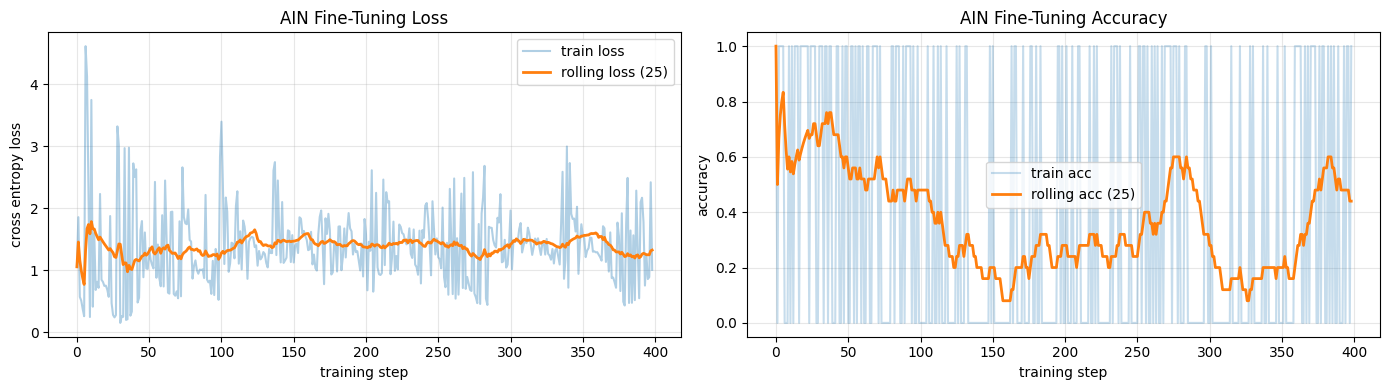

saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/loss/ain_coupled_reenv_loss_accuracy.png
final rolling loss: 1.325604622364044
final rolling acc: 0.44


In [9]:
# Losses

window = 25

train_loss = np.asarray(ain_train_loss, dtype=np.float32)
train_acc = np.asarray(ain_train_acc, dtype=np.float32)

rolling_loss = pd.Series(train_loss).rolling(window=window, min_periods=1).mean()
rolling_acc = pd.Series(train_acc).rolling(window=window, min_periods=1).mean()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(train_loss, alpha=0.35, label="train loss")
ax[0].plot(rolling_loss, linewidth=2, label=f"rolling loss ({window})")
ax[0].set_title("AIN Fine-Tuning Loss")
ax[0].set_xlabel("training step")
ax[0].set_ylabel("cross entropy loss")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(train_acc, alpha=0.25, label="train acc")
ax[1].plot(rolling_acc, linewidth=2, label=f"rolling acc ({window})")
ax[1].set_title("AIN Fine-Tuning Accuracy")
ax[1].set_xlabel("training step")
ax[1].set_ylabel("accuracy")
ax[1].set_ylim(-0.05, 1.05)
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()

plot_path = LOSS_PLOTS_DIR / "ain_coupled_reenv_loss_accuracy.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")

plt.show()

print("saved plot:", plot_path)
print("final rolling loss:", float(rolling_loss.iloc[-1]))
print("final rolling acc:", float(rolling_acc.iloc[-1]))

# Re-env Action Embedding

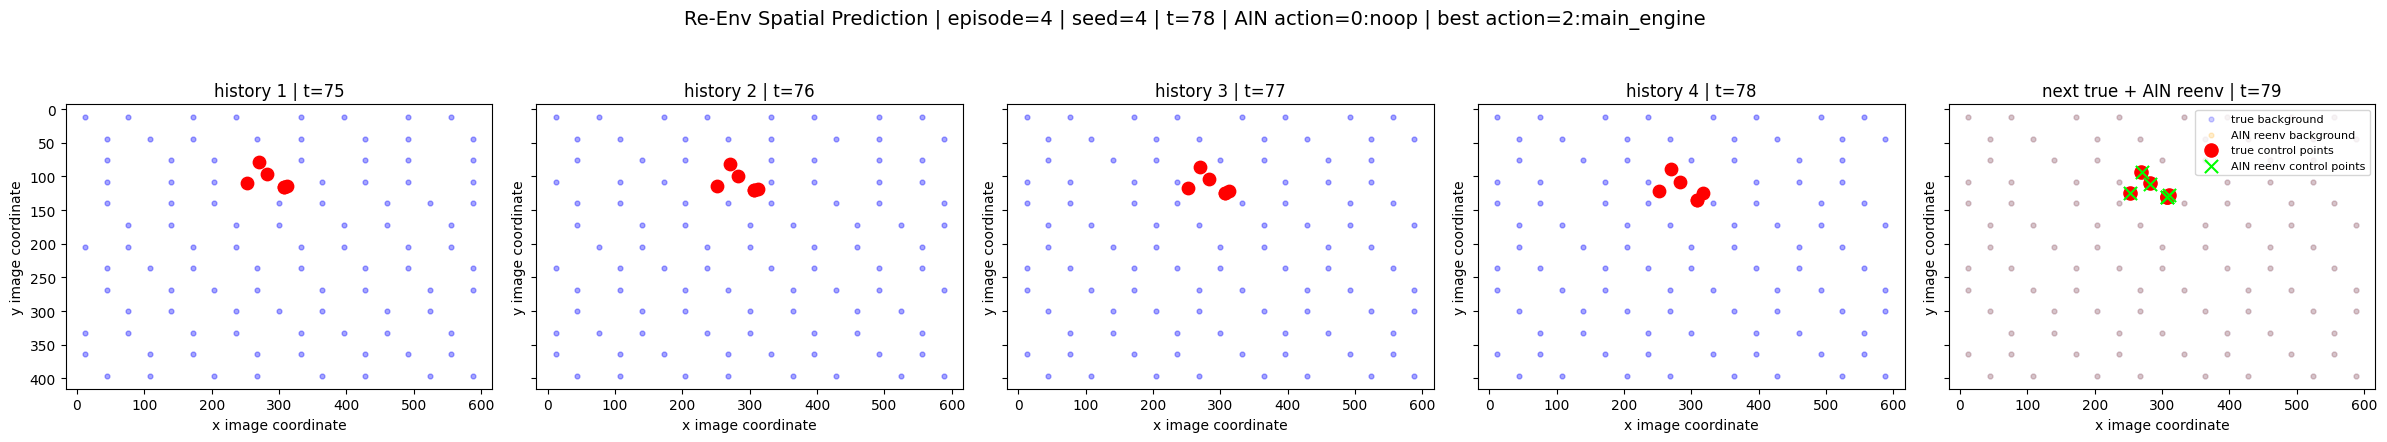

sample_episode_id: 4
seed: 4
history_ts: [75, 76, 77, 78]
next_t: 79
AIN action: 0 noop
best action: 2 main_engine
saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests/reenv_spatial_sequence_episode_0004_t_0078.png


In [17]:
# Re-Env Random Episode - Spatial Sequence Plot

BACKGROUND_GRID_STEP_LOCAL = globals().get("BACKGROUND_GRID_STEP", 32)
N_BACKGROUND_POINTS_LOCAL = globals().get("N_BACKGROUND_POINTS", 100)
ACTION_EFFECT_HORIZON_LOCAL = globals().get("ACTION_EFFECT_HORIZON", 5)

train_trace_df = reenv_trace_df[
    reenv_trace_df["phase"] == "train"
].copy()

sample_episode_id = np.random.choice(train_trace_df["episode_id"].unique())

episode_rows = train_trace_df[
    train_trace_df["episode_id"] == sample_episode_id
].sort_values("t").copy()

valid_rows = episode_rows[
    episode_rows["t"] >= seq_len
].copy()

sample_row = valid_rows.sample(
    n=1,
    random_state=np.random.randint(0, 1_000_000),
).iloc[0]

target_t = int(sample_row["t"])
seed = int(sample_row["seed"])
action_effect_horizon = int(sample_row.get("action_effect_horizon", ACTION_EFFECT_HORIZON_LOCAL))

history_ts = list(range(target_t - seq_len + 1, target_t + 1))
future_t = int(sample_row.get("future_t", target_t + action_effect_horizon))


def replay_reenv_frame(seed, episode_id, target_t):
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, info = env.reset(seed=int(seed))

    replay_rows = reenv_trace_df[
        (reenv_trace_df["episode_id"] == episode_id)
        & (reenv_trace_df["t"] < target_t)
    ].sort_values("t")

    for _, replay_row in replay_rows.iterrows():
        obs, reward, terminated, truncated, info = env.step(
            int(replay_row["action"])
        )

        if terminated or truncated:
            break

    frame = env.render()
    env.close()

    return frame


def frame_to_cp_bckg_xy(frame):
    records = lunar_lander_agent_records(frame)

    cp_rows = []

    for record in records:
        cp_rows.extend(control_points_from_record(record))

    cp_df = pd.DataFrame(cp_rows)

    bg_mask, active_mask, records_for_bg = surface_grid_background_mask(frame)

    bg_points = make_surface_grid_points(
        bg_mask,
        step=BACKGROUND_GRID_STEP_LOCAL,
    )

    selected_bg_points = select_fixed_background_points(
        bg_points,
        n_points=N_BACKGROUND_POINTS_LOCAL,
    )

    if len(cp_df):
        x_cp = cp_df["x"].to_numpy(dtype=np.float32)
        y_cp = cp_df["y"].to_numpy(dtype=np.float32)
    else:
        x_cp = np.asarray([], dtype=np.float32)
        y_cp = np.asarray([], dtype=np.float32)

    if len(selected_bg_points):
        x_bckg = selected_bg_points[:, 0].astype(np.float32)
        y_bckg = selected_bg_points[:, 1].astype(np.float32)
    else:
        x_bckg = np.asarray([], dtype=np.float32)
        y_bckg = np.asarray([], dtype=np.float32)

    return x_cp, y_cp, x_bckg, y_bckg


history_frames = [
    replay_reenv_frame(seed, sample_episode_id, t)
    for t in history_ts
]

true_future_frame = replay_reenv_frame(seed, sample_episode_id, future_t)

ain_action = int(sample_row["ain_pred_action"])

env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = env.reset(seed=seed)

replay_rows = reenv_trace_df[
    (reenv_trace_df["episode_id"] == sample_episode_id)
    & (reenv_trace_df["t"] < target_t)
].sort_values("t")

for _, replay_row in replay_rows.iterrows():
    obs, reward, terminated, truncated, info = env.step(
        int(replay_row["action"])
    )

    if terminated or truncated:
        break

for _ in range(action_effect_horizon):
    obs, reward, terminated, truncated, info = env.step(ain_action)
    if terminated or truncated:
        break

pred_future_frame = env.render()
env.close()

history_xy = [
    frame_to_cp_bckg_xy(frame)
    for frame in history_frames
]

true_xy = frame_to_cp_bckg_xy(true_future_frame)
pred_xy = frame_to_cp_bckg_xy(pred_future_frame)

fig, ax = plt.subplots(
    1,
    seq_len + 1,
    figsize=(24, 4),
    sharex=True,
    sharey=True,
)

for idx in range(seq_len):
    x_cp, y_cp, x_bckg, y_bckg = history_xy[idx]

    ax[idx].scatter(
        x_bckg,
        y_bckg,
        s=12,
        alpha=0.35,
        c="blue",
        label="background points",
    )

    ax[idx].scatter(
        x_cp,
        y_cp,
        s=80,
        c="red",
        label="control points",
    )

    ax[idx].invert_yaxis()
    ax[idx].set_title(f"history {idx + 1} | t={history_ts[idx]}")
    ax[idx].set_xlabel("x image coordinate")
    ax[idx].set_ylabel("y image coordinate")
    ax[idx].set_aspect("equal", adjustable="box")

x_cp_true, y_cp_true, x_bckg_true, y_bckg_true = true_xy
x_cp_pred, y_cp_pred, x_bckg_pred, y_bckg_pred = pred_xy

ax[-1].scatter(
    x_bckg_true,
    y_bckg_true,
    s=12,
    alpha=0.20,
    c="blue",
    label="true background",
)

ax[-1].scatter(
    x_bckg_pred,
    y_bckg_pred,
    s=12,
    alpha=0.20,
    c="orange",
    label="AIN reenv background",
)

ax[-1].scatter(
    x_cp_true,
    y_cp_true,
    s=90,
    c="red",
    label="true control points",
)

ax[-1].scatter(
    x_cp_pred,
    y_cp_pred,
    s=90,
    c="lime",
    marker="x",
    label="AIN reenv control points",
)

ax[-1].invert_yaxis()
ax[-1].set_title(f"future true + AIN reenv | t={future_t} | H={action_effect_horizon}")
ax[-1].set_xlabel("x image coordinate")
ax[-1].set_ylabel("y image coordinate")
ax[-1].set_aspect("equal", adjustable="box")
ax[-1].legend(loc="upper right", fontsize=8)

plt.suptitle(
    f"Re-Env Spatial Prediction | episode={sample_episode_id} | "
    f"seed={seed} | t={target_t} | H={action_effect_horizon} | "
    f"AIN action={ain_action}:{ACTION_NAMES[ain_action]} | "
    f"best action={int(sample_row['best_action'])}:{sample_row['best_action_name']}",
    fontsize=14,
    y=1.05,
)

plt.tight_layout()

plot_path = (
    AIN_PLOTS_DIR
    / f"reenv_spatial_sequence_episode_{int(sample_episode_id):04d}_t_{target_t:04d}_h_{action_effect_horizon}.png"
)

plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("sample_episode_id:", sample_episode_id)
print("seed:", seed)
print("history_ts:", history_ts)
print("future_t:", future_t)
print("action_effect_horizon:", action_effect_horizon)
print("AIN action:", ain_action, ACTION_NAMES[ain_action])
print("best action:", int(sample_row["best_action"]), sample_row["best_action_name"])
print("saved plot:", plot_path)


# Action Distribution

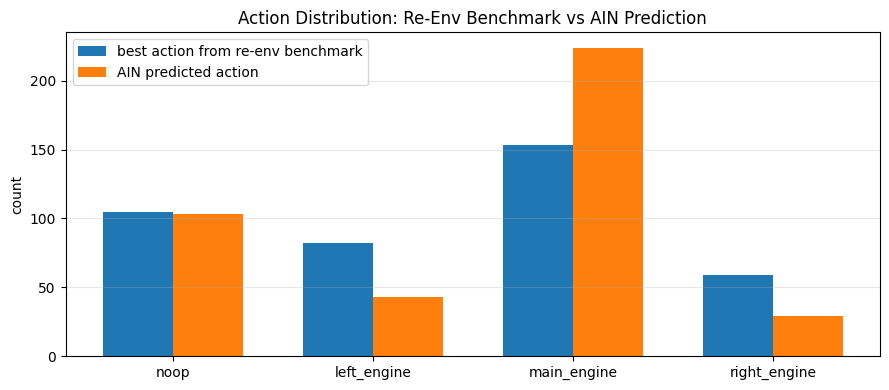

best action counts:
best_action
0    105
1     82
2    153
3     59

AIN predicted action counts:
ain_pred_action
0    103
1     43
2    224
3     29

saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests/action_distribution_best_vs_ain.png


In [20]:
# Action Distribution

train_rows = reenv_trace_df[
    reenv_trace_df["phase"] == "train"
].copy()

action_order = list(ACTION_NAMES.keys())
action_labels = [ACTION_NAMES[action_id] for action_id in action_order]

best_counts = (
    train_rows["best_action"]
    .astype(int)
    .value_counts()
    .reindex(action_order, fill_value=0)
)

ain_counts = (
    train_rows["ain_pred_action"]
    .astype(int)
    .value_counts()
    .reindex(action_order, fill_value=0)
)

x = np.arange(len(action_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    x - width / 2,
    best_counts.values,
    width,
    label="best action from re-env benchmark",
)

ax.bar(
    x + width / 2,
    ain_counts.values,
    width,
    label="AIN predicted action",
)

ax.set_xticks(x)
ax.set_xticklabels(action_labels)
ax.set_ylabel("count")
ax.set_title("Action Distribution: Re-Env Benchmark vs AIN Prediction")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = AIN_PLOTS_DIR / "action_distribution_best_vs_ain.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")

plt.show()

print("best action counts:")
print(best_counts.to_string())

print("\nAIN predicted action counts:")
print(ain_counts.to_string())

print("\nsaved plot:", plot_path)

# Confustion Matrix

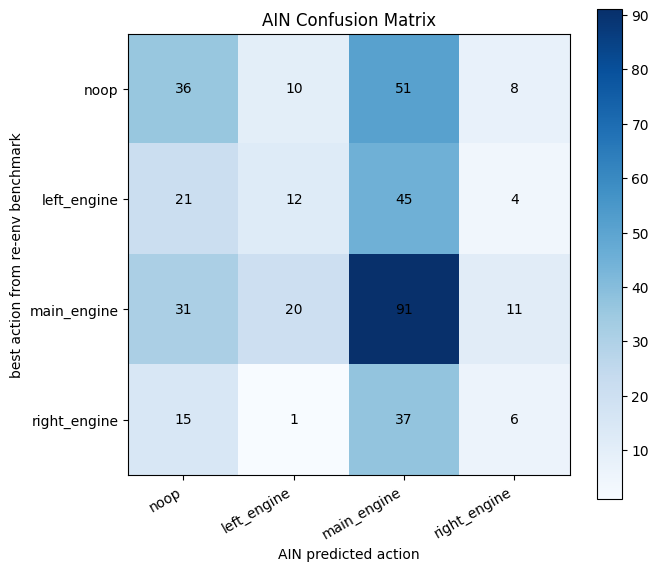

AIN predicted action   0   1   2   3
best action                         
0                     36  10  51   8
1                     21  12  45   4
2                     31  20  91  11
3                     15   1  37   6
saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests/ain_confusion_matrix.png


In [21]:
# Confusion Matrix

train_rows = reenv_trace_df[
    reenv_trace_df["phase"] == "train"
].copy()

y_true = train_rows["best_action"].astype(int).to_numpy()
y_pred = train_rows["ain_pred_action"].astype(int).to_numpy()

action_order = list(ACTION_NAMES.keys())
action_labels = [ACTION_NAMES[action_id] for action_id in action_order]

confusion = pd.crosstab(
    pd.Categorical(y_true, categories=action_order),
    pd.Categorical(y_pred, categories=action_order),
    rownames=["best action"],
    colnames=["AIN predicted action"],
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(confusion.values, cmap="Blues")

ax.set_xticks(np.arange(len(action_labels)))
ax.set_yticks(np.arange(len(action_labels)))

ax.set_xticklabels(action_labels, rotation=30, ha="right")
ax.set_yticklabels(action_labels)

ax.set_xlabel("AIN predicted action")
ax.set_ylabel("best action from re-env benchmark")
ax.set_title("AIN Confusion Matrix")

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(
            j,
            i,
            int(confusion.values[i, j]),
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)

plt.tight_layout()

plot_path = AIN_PLOTS_DIR / "ain_confusion_matrix.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")

plt.show()

print(confusion.to_string())
print("saved plot:", plot_path)

# Candidate Loss Margin

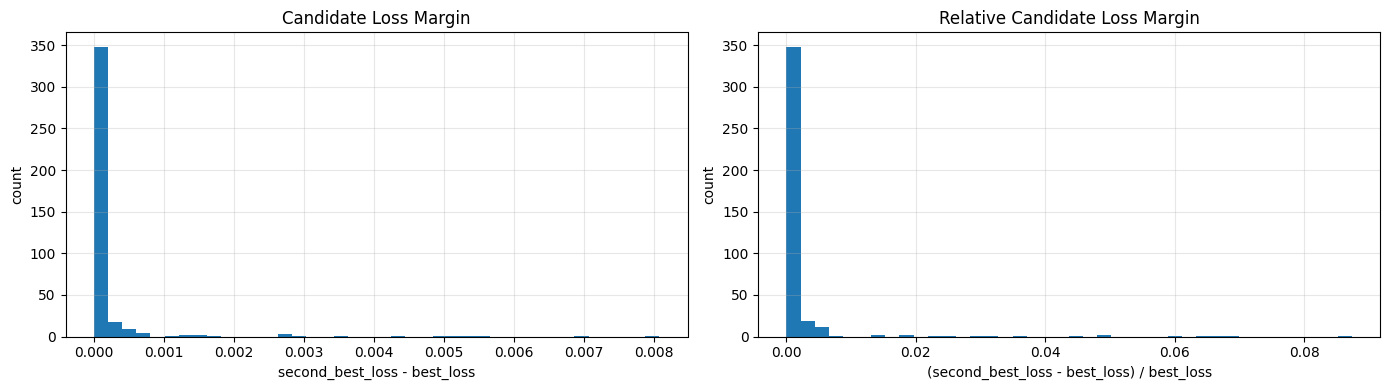

all train rows: 399
finite train rows: 396
dropped rows with inf: 3

loss margin describe:
count    396.000000
mean       0.000219
std        0.000845
min        0.000000
25%        0.000001
50%        0.000011
75%        0.000081
max        0.008071

relative margin describe:
count    396.000000
mean       0.002383
std        0.009464
min        0.000000
25%        0.000011
50%        0.000111
75%        0.000804
max        0.087366

small margin ratio:
margin < 1e-5: 0.494949494949495
margin < 1e-4: 0.7803030303030303
margin < 1e-3: 0.9545454545454546

saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests/candidate_loss_margin.png


In [24]:
# Candidate Loss Margin

train_rows = reenv_trace_df[
    reenv_trace_df["phase"] == "train"
].copy()

candidate_loss_cols = [
    "candidate_loss_noop",
    "candidate_loss_left_engine",
    "candidate_loss_main_engine",
    "candidate_loss_right_engine",
]

candidate_losses_all = train_rows[candidate_loss_cols].to_numpy(dtype=np.float32)

finite_mask = np.isfinite(candidate_losses_all).all(axis=1)

train_rows_finite = train_rows[finite_mask].copy()
candidate_losses = candidate_losses_all[finite_mask]

sorted_losses = np.sort(candidate_losses, axis=1)

best_loss = sorted_losses[:, 0]
second_best_loss = sorted_losses[:, 1]

loss_margin = second_best_loss - best_loss
relative_margin = loss_margin / (best_loss + 1e-8)

train_rows_finite["candidate_loss_margin"] = loss_margin
train_rows_finite["candidate_relative_margin"] = relative_margin

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(loss_margin, bins=40)
ax[0].set_title("Candidate Loss Margin")
ax[0].set_xlabel("second_best_loss - best_loss")
ax[0].set_ylabel("count")
ax[0].grid(alpha=0.3)

ax[1].hist(relative_margin, bins=40)
ax[1].set_title("Relative Candidate Loss Margin")
ax[1].set_xlabel("(second_best_loss - best_loss) / best_loss")
ax[1].set_ylabel("count")
ax[1].grid(alpha=0.3)

plt.tight_layout()

plot_path = AIN_PLOTS_DIR / "candidate_loss_margin.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")

plt.show()

print("all train rows:", len(train_rows))
print("finite train rows:", len(train_rows_finite))
print("dropped rows with inf:", int((~finite_mask).sum()))

print("\nloss margin describe:")
print(pd.Series(loss_margin).describe().to_string())

print("\nrelative margin describe:")
print(pd.Series(relative_margin).describe().to_string())

print("\nsmall margin ratio:")
print("margin < 1e-5:", float((loss_margin < 1e-5).mean()))
print("margin < 1e-4:", float((loss_margin < 1e-4).mean()))
print("margin < 1e-3:", float((loss_margin < 1e-3).mean()))

print("\nsaved plot:", plot_path)

# Multi-Step Candidate Rollout Benchmark

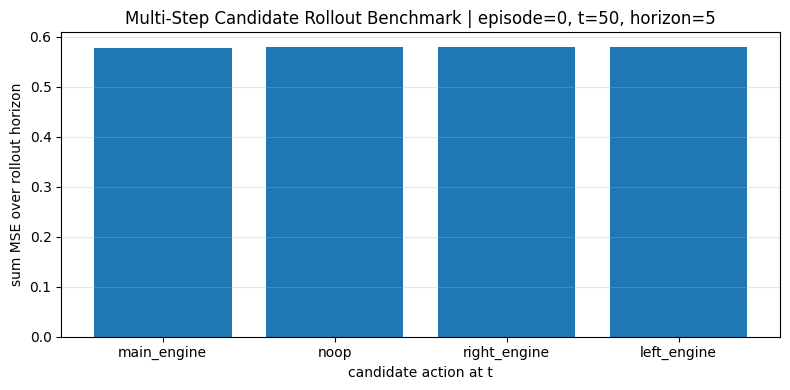

sample_episode_id: 0
seed: 0
target_t: 50
horizon: 5
single-step best action: 1 left_engine
multi-step best action: 2 main_engine

summary:
 candidate_action candidate_action_name  total_loss  mean_loss  valid_steps
                2           main_engine    0.578082   0.115616            5
                0                  noop    0.579882   0.115976            5
                3          right_engine    0.579920   0.115984            5
                1           left_engine    0.580147   0.116029            5

saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests/multistep_candidate_rollout_episode_0000_t_0050.png


In [25]:
# Multi-Step Candidate Rollout Benchmark

ROLLOUT_HORIZON = 5

train_rows = reenv_trace_df[
    reenv_trace_df["phase"] == "train"
].copy()

sample_row = train_rows.sample(
    n=1,
    random_state=np.random.randint(0, 1_000_000),
).iloc[0]

sample_episode_id = int(sample_row["episode_id"])
seed = int(sample_row["seed"])
target_t = int(sample_row["t"])

token_path = SOURCE_PRETRAIN_TOKENS_DIR / sample_row["token_file"]
token_data = np.load(token_path)

pretrain_tokens = token_data["tokens"].astype(np.float32)
pretrain_frames = token_data["frames"]

max_horizon = min(
    ROLLOUT_HORIZON,
    len(pretrain_tokens) - target_t - 1,
)

replay_actions = (
    reenv_trace_df[
        (reenv_trace_df["episode_id"] == sample_episode_id)
        & (reenv_trace_df["t"] < target_t)
    ]
    .sort_values("t")["action"]
    .astype(int)
    .tolist()
)

candidate_rollout_rows = []

for action_id, action_name in ACTION_NAMES.items():
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    for replay_action in replay_actions:
        obs, reward, terminated, truncated, info = env.step(int(replay_action))

        if terminated or truncated:
            break

    total_loss = 0.0
    valid_steps = 0
    rollout_actions = []

    for h in range(max_horizon):
        if h == 0:
            rollout_action = int(action_id)
        else:
            rollout_action = int(heuristic(env.unwrapped, obs))

        obs, reward, terminated, truncated, info = env.step(rollout_action)
        frame = env.render()

        embedding = frame_to_action_embedding(frame)

        if embedding is None:
            step_loss = np.inf
        else:
            pred_token = embedding["token"]
            true_token = pretrain_tokens[target_t + 1 + h]
            step_loss = float(np.mean((pred_token - true_token) ** 2))

        total_loss += step_loss
        valid_steps += int(np.isfinite(step_loss))
        rollout_actions.append(rollout_action)

        candidate_rollout_rows.append(
            {
                "episode_id": sample_episode_id,
                "seed": seed,
                "t": target_t,
                "candidate_action": int(action_id),
                "candidate_action_name": action_name,
                "h": h + 1,
                "frame_true": int(pretrain_frames[target_t + 1 + h]),
                "rollout_action": rollout_action,
                "rollout_action_name": ACTION_NAMES[rollout_action],
                "step_loss": step_loss,
                "terminated": bool(terminated),
                "truncated": bool(truncated),
            }
        )

        if terminated or truncated or not np.isfinite(step_loss):
            break

    env.close()

candidate_rollout_df = pd.DataFrame(candidate_rollout_rows)

summary_df = (
    candidate_rollout_df
    .groupby(["candidate_action", "candidate_action_name"], as_index=False)
    .agg(
        total_loss=("step_loss", "sum"),
        mean_loss=("step_loss", "mean"),
        valid_steps=("step_loss", lambda x: int(np.isfinite(x).sum())),
    )
    .sort_values("total_loss")
    .reset_index(drop=True)
)

best_multistep_action = int(summary_df.iloc[0]["candidate_action"])

plt.figure(figsize=(8, 4))

plt.bar(
    summary_df["candidate_action_name"],
    summary_df["total_loss"],
)

plt.title(
    f"Multi-Step Candidate Rollout Benchmark | "
    f"episode={sample_episode_id}, t={target_t}, horizon={max_horizon}"
)
plt.xlabel("candidate action at t")
plt.ylabel("sum MSE over rollout horizon")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plot_path = AIN_PLOTS_DIR / (
    f"multistep_candidate_rollout_episode_{sample_episode_id:04d}_t_{target_t:04d}.png"
)

plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("sample_episode_id:", sample_episode_id)
print("seed:", seed)
print("target_t:", target_t)
print("horizon:", max_horizon)
print("single-step best action:", int(sample_row["best_action"]), sample_row["best_action_name"])
print("multi-step best action:", best_multistep_action, ACTION_NAMES[best_multistep_action])
print("\nsummary:")
print(summary_df.to_string(index=False))
print("\nsaved plot:", plot_path)

# Random Episode Trace Review

sample_episode_id: 3
episode trace shape: (76, 21)
 global_step  episode_id  t  pretrain_frame_t  pretrain_frame_t1  action  action_name  best_action best_action_name  ain_pred_action ain_pred_action_name  ce_loss  train_acc  best_action_cp_bckg_loss  candidate_loss_noop  candidate_loss_left_engine  candidate_loss_main_engine  candidate_loss_right_engine  env_reward_after_best_action  terminated  truncated
         180           3  3                 6                  9       0         noop          0.0             noop              2.0          main_engine 1.860332        0.0                  0.072225             0.072225                    0.072247                    0.072245                     0.072225                     -0.652872       False      False
         181           3  4                 9                 11       1  left_engine          1.0      left_engine              2.0          main_engine 1.963723        0.0                  0.074121             0.078186           

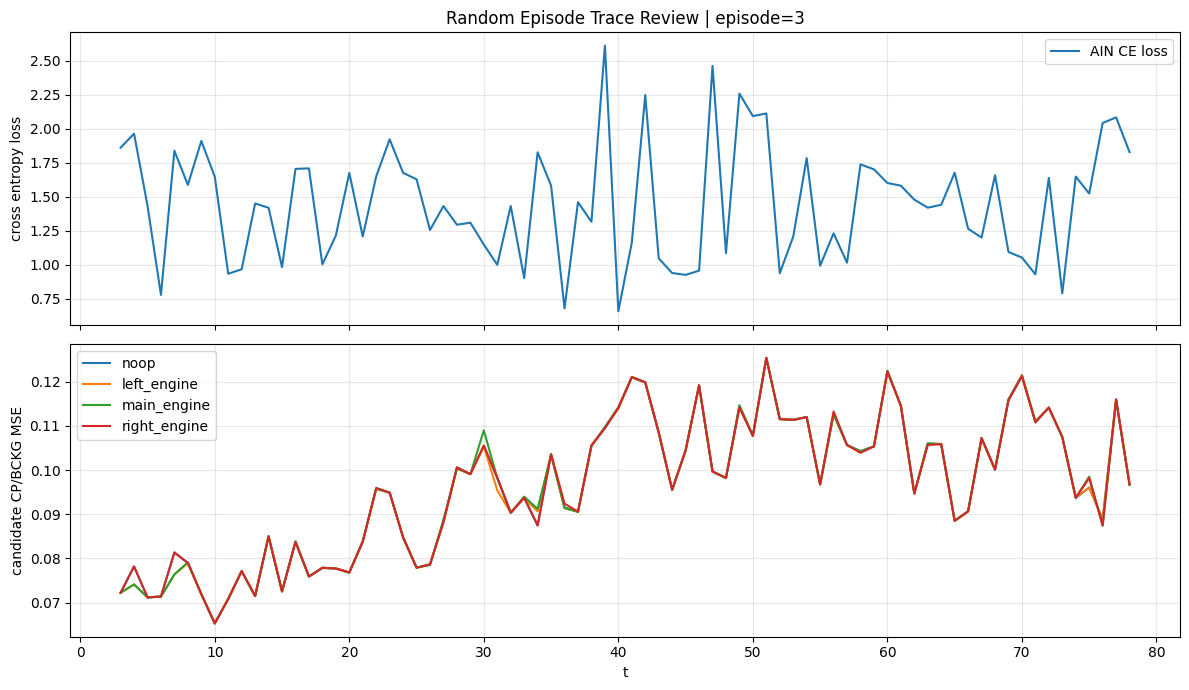

saved plot: /Users/adriankazi/Desktop/Action Inference/notebooks/artifacts/lunarlander_finetune/plots/ain_prediction_tests/random_episode_trace_review_0003.png


In [26]:
# Random Episode Trace Review

train_rows = reenv_trace_df[
    reenv_trace_df["phase"] == "train"
].copy()

sample_episode_id = np.random.choice(train_rows["episode_id"].unique())

episode_trace = train_rows[
    train_rows["episode_id"] == sample_episode_id
].sort_values("t").copy()

review_cols = [
    "global_step",
    "episode_id",
    "t",
    "pretrain_frame_t",
    "pretrain_frame_future",
    "future_t",
    "action_effect_horizon",
    "action",
    "action_name",
    "best_action",
    "best_action_name",
    "ain_pred_action",
    "ain_pred_action_name",
    "ce_loss",
    "train_acc",
    "best_action_cp_bckg_loss",
    "candidate_loss_noop",
    "candidate_loss_left_engine",
    "candidate_loss_main_engine",
    "candidate_loss_right_engine",
    "env_reward_after_best_action",
    "terminated",
    "truncated",
]

episode_review = episode_trace[review_cols].copy()

print("sample_episode_id:", sample_episode_id)
print("episode trace shape:", episode_review.shape)
print(episode_review.to_string(index=False))

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(
    episode_trace["t"],
    episode_trace["ce_loss"],
    label="AIN CE loss",
)
ax[0].set_ylabel("cross entropy loss")
ax[0].set_title(f"Random Episode Trace Review | episode={sample_episode_id}")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(
    episode_trace["t"],
    episode_trace["candidate_loss_noop"],
    label="noop",
)
ax[1].plot(
    episode_trace["t"],
    episode_trace["candidate_loss_left_engine"],
    label="left_engine",
)
ax[1].plot(
    episode_trace["t"],
    episode_trace["candidate_loss_main_engine"],
    label="main_engine",
)
ax[1].plot(
    episode_trace["t"],
    episode_trace["candidate_loss_right_engine"],
    label="right_engine",
)
ax[1].set_xlabel("t")
ax[1].set_ylabel("candidate CP/BCKG MSE")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()

plot_path = AIN_PLOTS_DIR / f"random_episode_trace_review_{int(sample_episode_id):04d}.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")

plt.show()

print("saved plot:", plot_path)